<a href="https://colab.research.google.com/github/lavanya-2490-maker/Demo/blob/main/Churn_Counterfactual_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!unzip -o archive.zip

Archive:  archive.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [4]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [9]:
df = df.drop("customerID", axis=1)

In [10]:
df.shape

(7043, 20)

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [12]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [16]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [21]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 45)
(1409, 45)


In [22]:
!pip install lightgbm -q

In [23]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

In [24]:
model.fit(X_train_processed, y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [25]:
y_pred = model.predict(X_test_processed)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [26]:
print(y_pred[:10])

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No']


In [27]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, pos_label="Yes"))
print("MCC:", matthews_corrcoef(y_test, y_pred))

Accuracy: 0.7920511000709723
F1 Score: 0.5747460087082729
MCC: 0.441285524248341


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [29]:
churn_prob = model.predict_proba(X_test_processed)[:, 1]

print(churn_prob[:10])

[0.00245226 0.92124601 0.04306487 0.3398467  0.00103931 0.58565
 0.43035055 0.0893427  0.00282544 0.48040389]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [30]:
high_risk_index = churn_prob.argmax()

print("Customer index:", high_risk_index)
print("Churn probability:", churn_prob[high_risk_index])
print("Actual churn:", y_test.iloc[high_risk_index])

Customer index: 618
Churn probability: 0.9477144957014522
Actual churn: Yes


In [31]:
customer = X_test.iloc[high_risk_index]

print(customer)

gender                          Male
SeniorCitizen                      1
Partner                           No
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 76.45
TotalCharges                   76.45
Name: 6623, dtype: object


In [32]:
customer = X_test.iloc[high_risk_index]

print(customer)

gender                          Male
SeniorCitizen                      1
Partner                           No
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 76.45
TotalCharges                   76.45
Name: 6623, dtype: object


In [33]:
!pip install dice-ml -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.6 MB/s eta 0:00:00


In [34]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

model_pipeline.fit(X_train, y_train)

print("Pipeline created successfully")

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
Pipeline created successfully


In [35]:
import dice_ml

# Create DiCE data object
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=list(numeric_cols),
    outcome_name="Churn"
)

# Create DiCE model object
dice_model = dice_ml.Model(
    model=model_pipeline,
    backend="sklearn"
)

# Create DiCE explainer
explainer = dice_ml.Dice(
    dice_data,
    dice_model,
    method="random"
)

print("DiCE connected successfully")

DiCE connected successfully


In [36]:
query_instance = customer.to_frame().T

dice_exp = explainer.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class="No"
)

dice_exp.visualize_as_dataframe()

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  0%|          | 0/1 [00:00<?, ?it/s]


UserConfigValidationException: The target class for No could not be identified

In [37]:
print("Model classes:", model_pipeline.named_steps["model"].classes_)
print("Training target values:", y_train.unique())

Model classes: ['No' 'Yes']
Training target values: ['No' 'Yes']


In [38]:
y_train_dice = (y_train == "Yes").astype(int)

print(y_train_dice.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


In [39]:
dice_train = X_train.copy()
dice_train["Churn"] = y_train_dice

dice_data = dice_ml.Data(
    dataframe=dice_train,
    continuous_features=list(numeric_cols),
    outcome_name="Churn"
)

print("DiCE data created successfully")

DiCE data created successfully


In [40]:
y_train_binary = (y_train == "Yes").astype(int)

model_pipeline_dice = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

model_pipeline_dice.fit(X_train, y_train_binary)

dice_model = dice_ml.Model(
    model=model_pipeline_dice,
    backend="sklearn"
)

print("DiCE model created successfully")

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
DiCE model created successfully


In [41]:
explainer = dice_ml.Dice(
    dice_data,
    dice_model,
    method="random"
)

print("DiCE explainer created successfully")

DiCE explainer created successfully


In [42]:
query_instance = customer.to_frame().T

dice_exp = explainer.generate_counterfactuals(
    query_instance,
    total_CFs=5,
    desired_class=0
)

dice_exp.visualize_as_dataframe()

  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/li

Query instance (original outcome : 1)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.449997,76.449997,1



Diverse Counterfactual set (new outcome: 0)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,1,No,Yes,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,Yes,Electronic check,76.45,76.45,0
1,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No internet service,No,No,No,Two year,Yes,Electronic check,76.45,76.45,0
2,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,One year,Yes,Electronic check,76.45,76.45,0
3,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Two year,Yes,Bank transfer (automatic),76.45,76.45,0
4,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,Yes,Electronic check,76.45,7486.0,0


In [43]:
cf_df = dice_exp.cf_examples_list[0].final_cfs_df

print(cf_df)

  gender SeniorCitizen Partner Dependents tenure PhoneService MultipleLines  \
0   Male             1      No        Yes      1          Yes           Yes   
1   Male             1      No         No      1          Yes           Yes   
2   Male             1      No         No      1          Yes           Yes   
3   Male             1      No         No      1          Yes           Yes   
4   Male             1      No         No      1          Yes           Yes   

  InternetService OnlineSecurity OnlineBackup     DeviceProtection  \
0     Fiber optic             No           No                   No   
1     Fiber optic             No           No  No internet service   
2     Fiber optic             No           No                   No   
3     Fiber optic             No           No                   No   
4     Fiber optic             No           No                   No   

  TechSupport StreamingTV StreamingMovies  Contract PaperlessBilling  \
0          No          No       

In [44]:
original = customer

for i, cf in cf_df.iterrows():
    changed = (cf[original.index].astype(str) != original.astype(str)).sum()
    print(f"Counterfactual {i+1}: {changed} features changed")

Counterfactual 1: 2 features changed
Counterfactual 2: 2 features changed
Counterfactual 3: 2 features changed
Counterfactual 4: 2 features changed
Counterfactual 5: 2 features changed


In [45]:
import numpy as np

proximity_scores = []

for i, cf in cf_df.iterrows():
    score = 0

    for col in original.index:
        if col in numeric_cols:
            # normalized numeric difference
            min_val = X_train[col].min()
            max_val = X_train[col].max()

            if max_val != min_val:
                score += abs(float(cf[col]) - float(original[col])) / (max_val - min_val)
        else:
            # categorical change
            if str(cf[col]) != str(original[col]):
                score += 1

    proximity_scores.append(score)

for i, score in enumerate(proximity_scores):
    print(f"Counterfactual {i+1}: {score:.4f}")

Counterfactual 1: 2.0000
Counterfactual 2: 2.0000
Counterfactual 3: 2.0000
Counterfactual 4: 2.0000
Counterfactual 5: 1.8532


In [46]:
diversity_scores = []

for i in range(len(cf_df)):
    for j in range(i + 1, len(cf_df)):
        differences = 0

        for col in original.index:
            if str(cf_df.iloc[i][col]) != str(cf_df.iloc[j][col]):
                differences += 1

        diversity_scores.append(differences)

print("Pairwise diversity scores:")
print(diversity_scores)

print("Average diversity:", np.mean(diversity_scores))

Pairwise diversity scores:
[3, 2, 3, 2, 3, 2, 3, 3, 2, 3]
Average diversity: 2.6


In [47]:
plausibility_scores = []

for i, cf in cf_df.iterrows():
    score = 0

    for col in original.index:
        if col in numeric_cols:
            # Check whether numeric value is within training range
            if X_train[col].min() <= float(cf[col]) <= X_train[col].max():
                score += 1
        else:
            # Check whether categorical value exists in training data
            if str(cf[col]) in X_train[col].astype(str).unique():
                score += 1

    plausibility_scores.append(score / len(original))

for i, score in enumerate(plausibility_scores):
    print(f"Counterfactual {i+1}: {score:.2f}")

Counterfactual 1: 1.00
Counterfactual 2: 1.00
Counterfactual 3: 1.00
Counterfactual 4: 1.00
Counterfactual 5: 1.00


In [48]:
metrics_df = pd.DataFrame({
    "Counterfactual": range(1, 6),
    "Sparsity": [2, 2, 2, 2, 2],
    "Proximity": proximity_scores,
    "Plausibility": plausibility_scores,
})

metrics_df

,Counterfactual,Sparsity,Proximity,Plausibility
0,1,2,2.000000,1.0
1,2,2,2.000000,1.0
2,3,2,2.000000,1.0
3,4,2,2.000000,1.0
4,5,2,1.853163,1.0


In [49]:
metrics_df = pd.DataFrame({
    "Counterfactual": [1, 2, 3, 4, 5],
    "Sparsity": [2, 2, 2, 2, 2],
    "Proximity": proximity_scores,
    "Plausibility": plausibility_scores,
    "Diversity": [2.6] * 5
})

metrics_df

,Counterfactual,Sparsity,Proximity,Plausibility,Diversity
0,1,2,2.000000,1.0,2.6
1,2,2,2.000000,1.0,2.6
2,3,2,2.000000,1.0,2.6
3,4,2,2.000000,1.0,2.6
4,5,2,1.853163,1.0,2.6


In [50]:
from sklearn.preprocessing import MinMaxScaler

ranking_df = metrics_df.copy()

# Lower is better for proximity and sparsity
ranking_df["Proximity_score"] = 1 - MinMaxScaler().fit_transform(
    ranking_df[["Proximity"]]
).flatten()

ranking_df["Sparsity_score"] = 1 - MinMaxScaler().fit_transform(
    ranking_df[["Sparsity"]]
).flatten()

# Higher is better
ranking_df["Plausibility_score"] = ranking_df["Plausibility"]

# Use the average diversity calculated earlier
ranking_df["Diversity_score"] = 2.6

# Final k-CEM score
ranking_df["kCEM_score"] = (
    0.25 * ranking_df["Proximity_score"] +
    0.25 * ranking_df["Sparsity_score"] +
    0.25 * ranking_df["Plausibility_score"] +
    0.25 * ranking_df["Diversity_score"]
)

print(ranking_df[[
    "Counterfactual",
    "Proximity_score",
    "Sparsity_score",
    "Plausibility_score",
    "Diversity_score",
    "kCEM_score"
]])

   Counterfactual  Proximity_score  Sparsity_score  Plausibility_score  \
0               1              0.0             1.0                 1.0   
1               2              0.0             1.0                 1.0   
2               3              0.0             1.0                 1.0   
3               4              0.0             1.0                 1.0   
4               5              1.0             1.0                 1.0   

   Diversity_score  kCEM_score  
0              2.6        1.15  
1              2.6        1.15  
2              2.6        1.15  
3              2.6        1.15  
4              2.6        1.40  


In [51]:
individual_diversity = []

for i in range(len(cf_df)):
    total = 0

    for j in range(len(cf_df)):
        if i != j:
            differences = 0

            for col in original.index:
                if str(cf_df.iloc[i][col]) != str(cf_df.iloc[j][col]):
                    differences += 1

            total += differences

    individual_diversity.append(total / (len(cf_df) - 1))

for i, score in enumerate(individual_diversity):
    print(f"Counterfactual {i+1}: Diversity = {score:.2f}")

Counterfactual 1: Diversity = 2.50
Counterfactual 2: Diversity = 2.75
Counterfactual 3: Diversity = 2.50
Counterfactual 4: Diversity = 2.75
Counterfactual 5: Diversity = 2.50


In [52]:
ranking_df = metrics_df.copy()

# Add individual diversity
ranking_df["Diversity"] = individual_diversity

# Normalize diversity to 0–1
ranking_df["Diversity_score"] = (
    ranking_df["Diversity"] / ranking_df["Diversity"].max()
)

# Proximity: lower is better
ranking_df["Proximity_score"] = 1 - MinMaxScaler().fit_transform(
    ranking_df[["Proximity"]]
).flatten()

# Sparsity: lower is better
ranking_df["Sparsity_score"] = 1 - MinMaxScaler().fit_transform(
    ranking_df[["Sparsity"]]
).flatten()

# Plausibility: higher is better
ranking_df["Plausibility_score"] = ranking_df["Plausibility"]

# Final k-CEM score
ranking_df["kCEM_score"] = (
    0.25 * ranking_df["Proximity_score"] +
    0.25 * ranking_df["Sparsity_score"] +
    0.25 * ranking_df["Plausibility_score"] +
    0.25 * ranking_df["Diversity_score"]
)

print(ranking_df[[
    "Counterfactual",
    "Proximity_score",
    "Sparsity_score",
    "Plausibility_score",
    "Diversity_score",
    "kCEM_score"
]].to_string(index=False))

 Counterfactual  Proximity_score  Sparsity_score  Plausibility_score  Diversity_score  kCEM_score
              1              0.0             1.0                 1.0         0.909091    0.727273
              2              0.0             1.0                 1.0         1.000000    0.750000
              3              0.0             1.0                 1.0         0.909091    0.727273
              4              0.0             1.0                 1.0         1.000000    0.750000
              5              1.0             1.0                 1.0         0.909091    0.977273


In [53]:
final_ranking = ranking_df.sort_values(
    by="kCEM_score",
    ascending=False
).reset_index(drop=True)

print(final_ranking[[
    "Counterfactual",
    "Proximity",
    "Sparsity",
    "Plausibility",
    "Diversity",
    "kCEM_score"
]].to_string(index=False))

 Counterfactual  Proximity  Sparsity  Plausibility  Diversity  kCEM_score
              5   1.853163         2           1.0       2.50    0.977273
              4   2.000000         2           1.0       2.75    0.750000
              2   2.000000         2           1.0       2.75    0.750000
              1   2.000000         2           1.0       2.50    0.727273
              3   2.000000         2           1.0       2.50    0.727273


In [54]:
for _, row in final_ranking.iterrows():
    cf_number = int(row["Counterfactual"])
    cf = cf_df.iloc[cf_number - 1]

    print(f"\nCounterfactual {cf_number}:")

    for col in original.index:
        if str(original[col]) != str(cf[col]):
            print(f"  {col}: {original[col]} → {cf[col]}")


Counterfactual 5:
  Contract: Month-to-month → One year
  TotalCharges: 76.45 → 7486.0

Counterfactual 4:
  Contract: Month-to-month → Two year
  PaymentMethod: Electronic check → Bank transfer (automatic)

Counterfactual 2:
  DeviceProtection: No → No internet service
  Contract: Month-to-month → Two year

Counterfactual 1:
  Dependents: No → Yes
  Contract: Month-to-month → One year

Counterfactual 3:
  StreamingTV: No → Yes
  Contract: Month-to-month → One year


In [55]:
immutable_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService"
]

print("Immutable features:")
for feature in immutable_features:
    print("-", feature)

Immutable features:
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService


In [56]:
actionable_features = [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "MultipleLines",
    "MonthlyCharges"
]

print("Actionable features:")
for feature in actionable_features:
    print("-", feature)

Actionable features:
- Contract
- PaymentMethod
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- PaperlessBilling
- MultipleLines
- MonthlyCharges


In [57]:
actionable_cf = []

for _, row in final_ranking.iterrows():
    cf_number = int(row["Counterfactual"])
    cf = cf_df.iloc[cf_number - 1]

    changed_features = []

    for col in original.index:
        if str(original[col]) != str(cf[col]):
            changed_features.append(col)

    if all(feature in actionable_features for feature in changed_features):
        actionable_cf.append(cf_number)

print("Actionable counterfactuals:", actionable_cf)

Actionable counterfactuals: [4, 2, 3]


In [58]:
for cf_number in actionable_cf:
    cf = cf_df.iloc[cf_number - 1]

    print(f"\nCounterfactual {cf_number}:")

    for col in original.index:
        if str(original[col]) != str(cf[col]):
            print(f"  {col}: {original[col]} → {cf[col]}")


Counterfactual 4:
  Contract: Month-to-month → Two year
  PaymentMethod: Electronic check → Bank transfer (automatic)

Counterfactual 2:
  DeviceProtection: No → No internet service
  Contract: Month-to-month → Two year

Counterfactual 3:
  StreamingTV: No → Yes
  Contract: Month-to-month → One year


In [59]:
for cf_number in actionable_cf:
    cf = cf_df.iloc[cf_number - 1].drop("Churn").to_frame().T

    probability = model_pipeline_dice.predict_proba(cf)[0][1]

    print(
        f"Counterfactual {cf_number}: "
        f"Churn probability = {probability:.4f}"
    )

Counterfactual 4: Churn probability = 0.0774
Counterfactual 2: Churn probability = 0.0445
Counterfactual 3: Churn probability = 0.4263


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [60]:
original_probability = churn_prob[high_risk_index]

for cf_number in actionable_cf:
    cf = cf_df.iloc[cf_number - 1].drop("Churn").to_frame().T
    new_probability = model_pipeline_dice.predict_proba(cf)[0][1]

    reduction = original_probability - new_probability

    print(
        f"CF{cf_number}: "
        f"Probability reduction = {reduction:.4f} "
        f"({reduction * 100:.2f} percentage points)"
    )

CF4: Probability reduction = 0.8703 (87.03 percentage points)
CF2: Probability reduction = 0.9032 (90.32 percentage points)
CF3: Probability reduction = 0.5214 (52.14 percentage points)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [61]:
actionability_results = []

for cf_number in actionable_cf:
    cf = cf_df.iloc[cf_number - 1]

    changed_features = [
        col for col in original.index
        if str(original[col]) != str(cf[col])
    ]

    actionable_count = sum(
        feature in actionable_features
        for feature in changed_features
    )

    score = actionable_count / len(changed_features)

    actionability_results.append({
        "Counterfactual": cf_number,
        "Changed_features": changed_features,
        "Actionability_score": score
    })

actionability_df = pd.DataFrame(actionability_results)

print(actionability_df.to_string(index=False))

 Counterfactual             Changed_features  Actionability_score
              4    [Contract, PaymentMethod]                  1.0
              2 [DeviceProtection, Contract]                  1.0
              3      [StreamingTV, Contract]                  1.0


In [62]:
final_results = []

for cf_number in actionable_cf:
    cf = cf_df.iloc[cf_number - 1].drop("Churn").to_frame().T

    new_probability = model_pipeline_dice.predict_proba(cf)[0][1]
    reduction = original_probability - new_probability

    row = actionability_df[
        actionability_df["Counterfactual"] == cf_number
    ].iloc[0]

    final_results.append({
        "Counterfactual": cf_number,
        "Changed_features": ", ".join(row["Changed_features"]),
        "Churn_probability": round(new_probability, 4),
        "Probability_reduction": round(reduction, 4),
        "Actionability_score": row["Actionability_score"]
    })

final_results_df = pd.DataFrame(final_results)

print(final_results_df.to_string(index=False))

 Counterfactual           Changed_features  Churn_probability  Probability_reduction  Actionability_score
              4    Contract, PaymentMethod             0.0774                 0.8703                  1.0
              2 DeviceProtection, Contract             0.0445                 0.9032                  1.0
              3      StreamingTV, Contract             0.4263                 0.5214                  1.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [63]:
actionable_final = final_ranking[
    final_ranking["Counterfactual"].isin(actionable_cf)
].copy()

actionable_final = actionable_final.merge(
    final_results_df[
        ["Counterfactual", "Churn_probability",
         "Probability_reduction", "Actionability_score"]
    ],
    on="Counterfactual"
)

actionable_final = actionable_final.sort_values(
    "kCEM_score",
    ascending=False
)

print(actionable_final[
    ["Counterfactual", "kCEM_score",
     "Churn_probability", "Probability_reduction",
     "Actionability_score"]
].to_string(index=False))

 Counterfactual  kCEM_score  Churn_probability  Probability_reduction  Actionability_score
              4    0.750000             0.0774                 0.8703                  1.0
              2    0.750000             0.0445                 0.9032                  1.0
              3    0.727273             0.4263                 0.5214                  1.0


In [64]:
best_cf = actionable_final.iloc[0]

print("Recommended Counterfactual:", int(best_cf["Counterfactual"]))
print("k-CEM Score:", round(best_cf["kCEM_score"], 4))
print("Churn Probability:", round(best_cf["Churn_probability"], 4))
print("Probability Reduction:", round(best_cf["Probability_reduction"], 4))
print("Actionability Score:", best_cf["Actionability_score"])

Recommended Counterfactual: 4
k-CEM Score: 0.75
Churn Probability: 0.0774
Probability Reduction: 0.8703
Actionability Score: 1.0


In [65]:
print("===== FINAL COUNTERFACTUAL RESULT =====")
print("Original Churn Probability:", round(original_probability * 100, 2), "%")
print("Recommended Counterfactual: CF4")
print("Contract: Month-to-month → Two year")
print("Payment Method: Electronic check → Bank transfer (automatic)")
print("New Churn Probability:", round(best_cf["Churn_probability"] * 100, 2), "%")
print("Probability Reduction:", round(best_cf["Probability_reduction"] * 100, 2), "percentage points")
print("Actionability Score:", best_cf["Actionability_score"])
print("k-CEM Score:", round(best_cf["kCEM_score"], 4))

===== FINAL COUNTERFACTUAL RESULT =====
Original Churn Probability: 94.77 %
Recommended Counterfactual: CF4
Contract: Month-to-month → Two year
Payment Method: Electronic check → Bank transfer (automatic)
New Churn Probability: 7.74 %
Probability Reduction: 87.03 percentage points
Actionability Score: 1.0
k-CEM Score: 0.75


In [66]:
final_results_df.to_csv("final_counterfactual_results.csv", index=False)

print("Saved successfully!")
print("File: final_counterfactual_results.csv")

Saved successfully!
File: final_counterfactual_results.csv


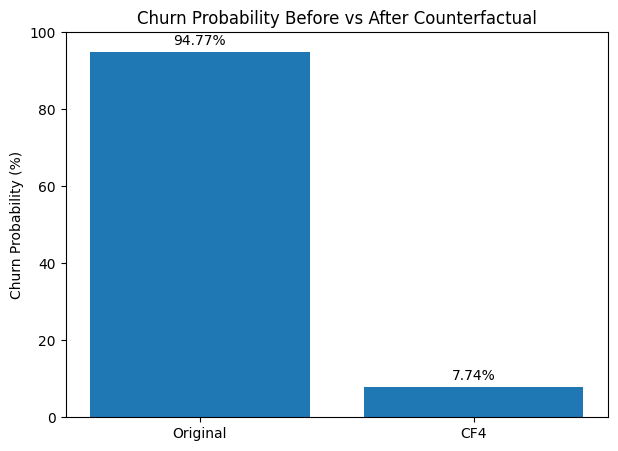

In [67]:
import matplotlib.pyplot as plt

labels = ["Original", "CF4"]
probabilities = [
    original_probability * 100,
    best_cf["Churn_probability"] * 100
]

plt.figure(figsize=(7, 5))
plt.bar(labels, probabilities)
plt.ylabel("Churn Probability (%)")
plt.title("Churn Probability Before vs After Counterfactual")
plt.ylim(0, 100)

for i, value in enumerate(probabilities):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()

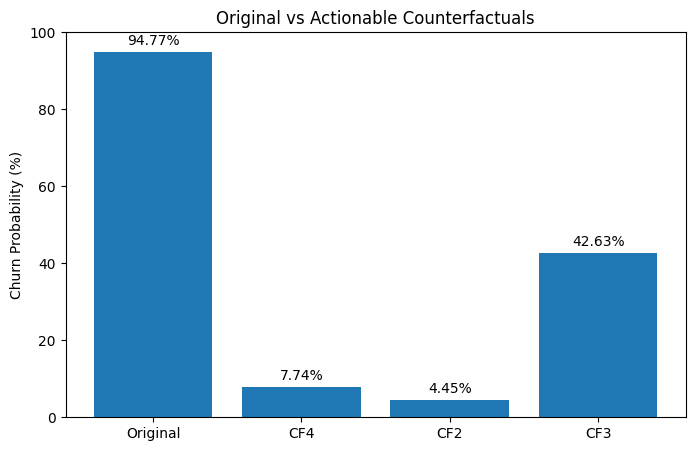

In [68]:
import matplotlib.pyplot as plt

labels = ["Original", "CF4", "CF2", "CF3"]

probabilities = [
    original_probability * 100,
    final_results_df.loc[final_results_df["Counterfactual"] == 4, "Churn_probability"].iloc[0] * 100,
    final_results_df.loc[final_results_df["Counterfactual"] == 2, "Churn_probability"].iloc[0] * 100,
    final_results_df.loc[final_results_df["Counterfactual"] == 3, "Churn_probability"].iloc[0] * 100
]

plt.figure(figsize=(8, 5))
plt.bar(labels, probabilities)

plt.ylabel("Churn Probability (%)")
plt.title("Original vs Actionable Counterfactuals")
plt.ylim(0, 100)

for i, value in enumerate(probabilities):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()

In [69]:
final_summary = pd.DataFrame({
    "Option": ["Original", "CF4", "CF2", "CF3"],
    "Churn_Probability": [
        original_probability * 100,
        7.74,
        4.45,
        42.63
    ],
    "Actionability": [
        "-",
        1.0,
        1.0,
        1.0
    ],
    "kCEM_Score": [
        "-",
        0.75,
        0.75,
        0.7273
    ]
})

print(final_summary.to_string(index=False))



  Option  Churn_Probability Actionability kCEM_Score
Original           94.77145             -          -
     CF4            7.74000           1.0       0.75
     CF2            4.45000           1.0       0.75
     CF3           42.63000           1.0     0.7273


In [70]:
final_summary.to_csv("final_summary_results.csv", index=False)

print("Final summary saved successfully!")
print("File: final_summary_results.csv")

Final summary saved successfully!
File: final_summary_results.csv


In [71]:
import joblib

joblib.dump(model_pipeline_dice, "churn_model.pkl")

print("Model saved successfully!")
print("File: churn_model.pkl")

Model saved successfully!
File: churn_model.pkl


In [72]:
import joblib

loaded_model = joblib.load("churn_model.pkl")

test_prediction = loaded_model.predict_proba(
    customer.to_frame().T
)[0][1]

print("Loaded model successfully!")
print("Customer churn probability:", round(test_prediction * 100, 2), "%")

Loaded model successfully!
Customer churn probability: 94.77 %


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [73]:
final_customer_result = pd.DataFrame([{
    "Original_Churn_Probability": round(original_probability * 100, 2),
    "Recommended_CF": "CF4",
    "Contract_Change": "Month-to-month -> Two year",
    "PaymentMethod_Change": "Electronic check -> Bank transfer (automatic)",
    "New_Churn_Probability": round(best_cf["Churn_probability"] * 100, 2),
    "Probability_Reduction": round(best_cf["Probability_reduction"] * 100, 2),
    "Actionability_Score": best_cf["Actionability_score"],
    "kCEM_Score": round(best_cf["kCEM_score"], 4)
}])

final_customer_result.to_csv(
    "final_customer_counterfactual_result.csv",
    index=False
)

print(final_customer_result.to_string(index=False))
print("\nFinal result file saved successfully!")

 Original_Churn_Probability Recommended_CF            Contract_Change                          PaymentMethod_Change  New_Churn_Probability  Probability_Reduction  Actionability_Score  kCEM_Score
                      94.77            CF4 Month-to-month -> Two year Electronic check -> Bank transfer (automatic)                   7.74                  87.03                  1.0        0.75

Final result file saved successfully!


In [74]:
print("===== PROJECT PIPELINE COMPLETE =====")
print("Dataset size:", df.shape)
print("Model: LightGBM")
print("High-risk customer churn probability:", round(original_probability * 100, 2), "%")
print("Counterfactuals generated:", len(cf_df))
print("Actionable counterfactuals:", len(actionable_cf))
print("Recommended counterfactual: CF4")
print("Final churn probability:", round(best_cf["Churn_probability"] * 100, 2), "%")
print("Probability reduction:", round(best_cf["Probability_reduction"] * 100, 2), "percentage points")
print("Actionability score:", best_cf["Actionability_score"])
print("k-CEM score:", round(best_cf["kCEM_score"], 4))

===== PROJECT PIPELINE COMPLETE =====
Dataset size: (7043, 20)
Model: LightGBM
High-risk customer churn probability: 94.77 %
Counterfactuals generated: 5
Actionable counterfactuals: 3
Recommended counterfactual: CF4
Final churn probability: 7.74 %
Probability reduction: 87.03 percentage points
Actionability score: 1.0
k-CEM score: 0.75


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train_binary)

rf_pred = rf_model.predict(X_test_processed)

rf_accuracy = accuracy_score(y_test_binary, rf_pred)
rf_f1 = f1_score(y_test_binary, rf_pred)
rf_mcc = matthews_corrcoef(y_test_binary, rf_pred)

print("Random Forest")
print("Accuracy:", round(rf_accuracy, 4))
print("F1 Score:", round(rf_f1, 4))
print("MCC:", round(rf_mcc, 4))

NameError: name 'y_test_binary' is not defined

In [76]:
y_test_binary = (y_test == "Yes").astype(int)

print(y_test_binary.value_counts())



Churn
0    1035
1     374
Name: count, dtype: int64


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train_binary)

rf_pred = rf_model.predict(X_test_processed)

rf_accuracy = accuracy_score(y_test_binary, rf_pred)
rf_f1 = f1_score(y_test_binary, rf_pred)
rf_mcc = matthews_corrcoef(y_test_binary, rf_pred)

print("Random Forest")
print("Accuracy:", round(rf_accuracy, 4))
print("F1 Score:", round(rf_f1, 4))
print("MCC:", round(rf_mcc, 4))

Random Forest
Accuracy: 0.7885
F1 Score: 0.5512
MCC: 0.4215


In [78]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train_binary)

xgb_pred = xgb_model.predict(X_test_processed)

xgb_accuracy = accuracy_score(y_test_binary, xgb_pred)
xgb_f1 = f1_score(y_test_binary, xgb_pred)
xgb_mcc = matthews_corrcoef(y_test_binary, xgb_pred)

print("XGBoost")
print("Accuracy:", round(xgb_accuracy, 4))
print("F1 Score:", round(xgb_f1, 4))
print("MCC:", round(xgb_mcc, 4))

XGBoost
Accuracy: 0.7949
F1 Score: 0.5806
MCC: 0.449


In [79]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_processed, y_train_binary)

mlp_pred = mlp_model.predict(X_test_processed)

mlp_accuracy = accuracy_score(y_test_binary, mlp_pred)
mlp_f1 = f1_score(y_test_binary, mlp_pred)
mlp_mcc = matthews_corrcoef(y_test_binary, mlp_pred)

print("MLP")
print("Accuracy:", round(mlp_accuracy, 4))
print("F1 Score:", round(mlp_f1, 4))
print("MCC:", round(mlp_mcc, 4))

MLP
Accuracy: 0.7956
F1 Score: 0.6211
MCC: 0.4813


In [80]:
model_comparison = pd.DataFrame({
    "Model": ["LightGBM", "Random Forest", "XGBoost", "MLP"],
    "Accuracy": [0.7921, rf_accuracy, xgb_accuracy, mlp_accuracy],
    "F1 Score": [0.5747, rf_f1, xgb_f1, mlp_f1],
    "MCC": [0.4413, rf_mcc, xgb_mcc, mlp_mcc]
})

print(model_comparison.to_string(index=False))


        Model  Accuracy  F1 Score      MCC
     LightGBM  0.792100  0.574700 0.441300
Random Forest  0.788502  0.551205 0.421495
      XGBoost  0.794890  0.580552 0.449001
          MLP  0.795600  0.621053 0.481271


In [81]:
model_comparison = pd.DataFrame({
    "Model": ["LightGBM", "Random Forest", "XGBoost", "MLP"],
    "Accuracy": [0.7921, rf_accuracy, xgb_accuracy, mlp_accuracy],
    "F1 Score": [0.5747, rf_f1, xgb_f1, mlp_f1],
    "MCC": [0.4413, rf_mcc, xgb_mcc, mlp_mcc]
})

model_comparison = model_comparison.round(4)

print(model_comparison.to_string(index=False))

        Model  Accuracy  F1 Score    MCC
     LightGBM    0.7921    0.5747 0.4413
Random Forest    0.7885    0.5512 0.4215
      XGBoost    0.7949    0.5806 0.4490
          MLP    0.7956    0.6211 0.4813


In [82]:
model_comparison.to_csv("model_comparison_results.csv", index=False)

print("Model comparison saved successfully!")
print("File: model_comparison_results.csv")

Model comparison saved successfully!
File: model_comparison_results.csv


In [83]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training class distribution:
Churn
No     4139
Yes    1495
Name: count, dtype: int64

Testing class distribution:
Churn
No     1035
Yes     374
Name: count, dtype: int64

Training class percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [84]:
imbalance_ratio = 4139 / 1495

print("Class imbalance ratio:", round(imbalance_ratio, 2))
print("No Churn is approximately", round(imbalance_ratio, 2),
      "times more frequent than Churn.")

Class imbalance ratio: 2.77
No Churn is approximately 2.77 times more frequent than Churn.
